In [ ]:
import numpy as np
import pandas as pd # Operaciones con dataframes
from matplotlib import pyplot as plt # gráficos
from statsmodels.tsa.seasonal import seasonal_decompose # descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # Holwinters simple
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holwinters doble y tripe
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error


In [ ]:
data = pd.read_excel("https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
data.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


Ejercicio

Empleando la información del número de ocupados en miles de personas (Ocupados) para las 13 principales ciudades, encuentre el mejor pronóstico para los próximos 6 meses. Escriba un breve informe de máximo una página de texto que explique cómo llega a sus proyeccciones y presente las proyecciones. Aclare en el texto cuáles serían las limitaciones de sus pronósticos.

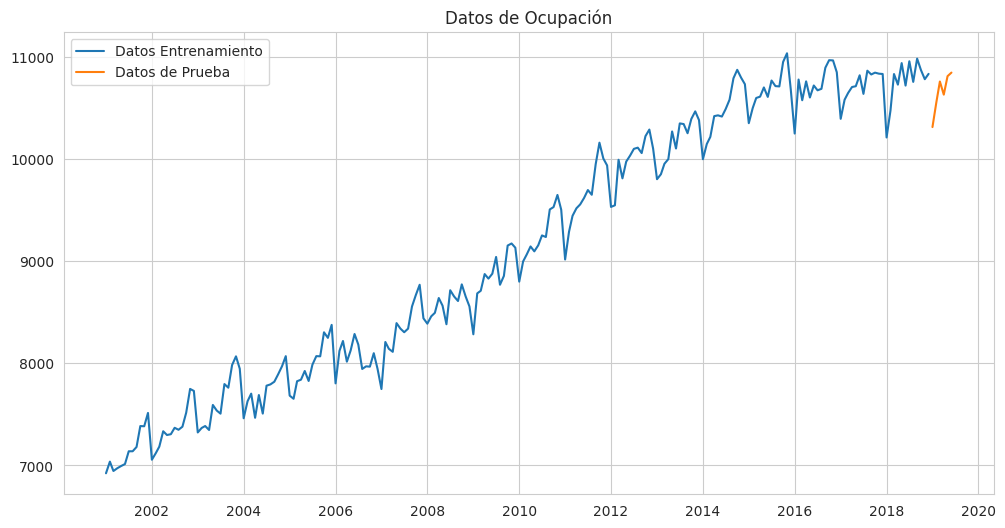

In [ ]:
train_len = 208
train_td = data[["Ocupados"]][:-6]
test_td = data[["Ocupados"]][-6:]

fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(test_td,label="Datos de Prueba")
plt.title("Datos de Ocupación")
plt.legend()
plt.show()

1. Suavización exponencial lineal aditiva

In [ ]:
# modelo aditivo
ets_model = ETSModel(endog=train_td["Ocupados"],error="add",trend="add",seasonal="add",
    seasonal_periods=12,
    damped_trend=True                     )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(6)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_hw_add = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_add.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_add)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


            Point_forecast      lower_95      upper_95
2019-01-01    10300.239189  10035.269096  10565.209283
2019-02-01    10561.539302  10277.473959  10845.604646
2019-03-01    10691.712277  10389.012062  10994.412492
2019-04-01    10691.644174  10370.688986  11012.599363
2019-05-01    10763.169933  10424.278548  11102.061319
2019-06-01    10707.149907  10350.593736  11063.706078


2. Suavización exponencial lineal multiplicativa

In [ ]:
# modelo multiplicativo

ets_model2 = ETSModel(endog=train_td["Ocupados"],error="add",trend="add",seasonal="mul",
    seasonal_periods=12,
    damped_trend=True  )

ets_result2 = ets_model2.fit()

point_forecast2=ets_result2.forecast(6)

ci2 = ets_result2.get_prediction(start = point_forecast2.index[0],
                                end = point_forecast2.index[-1])

conf_forecast2 = ci2.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci2.predicted_mean


preds_hw_mul = pd.concat([limits, conf_forecast2], axis = 1)
preds_hw_mul.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_mul)

            Point_forecast      lower_95      upper_95
2019-01-01    10335.072006  10112.263871  10578.022667
2019-02-01    10533.634310  10276.111351  10774.238161
2019-03-01    10617.283934  10347.513752  10901.275210
2019-04-01    10627.035371  10290.335565  10946.479908
2019-05-01    10695.724960  10363.060758  11038.701887
2019-06-01    10652.066321  10283.963687  11034.805698


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


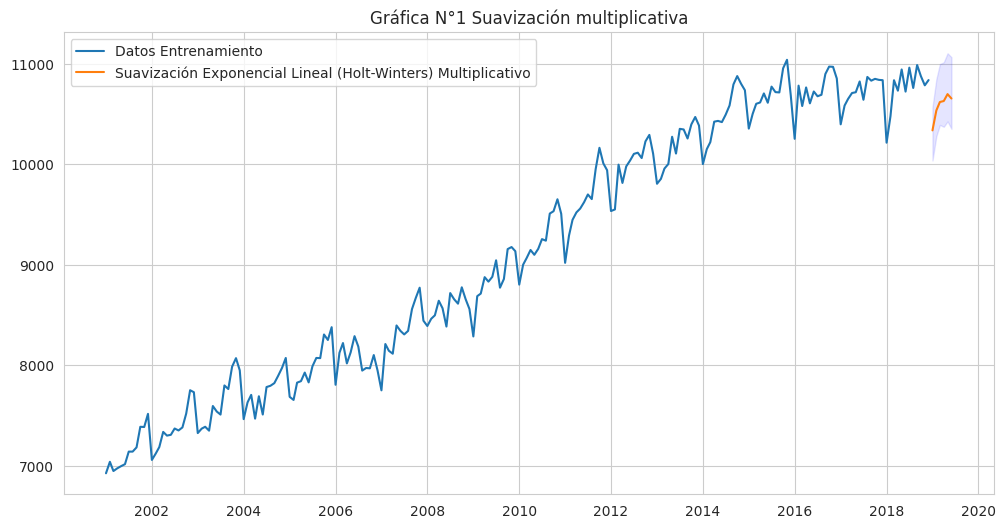

In [ ]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
#plt.plot(preds_hw_add['Point_forecast'],label="Suavización Exponencial Lineal (Holt-Winters) Aditivo")
plt.plot(preds_hw_mul['Point_forecast'],label="Suavización Exponencial Lineal (Holt-Winters) Multiplicativo")
plt.fill_between(preds_hw_add.index ,preds_hw_add['lower_95'], preds_hw_add['upper_95'], color='blue', alpha=0.1)
plt.title("Gráfica N°1 Suavización multiplicativa")
plt.legend()
plt.show()

3. Variación de parámetros

Inicialmente, se propone hacer pequeñas variaciones en los parámetros en ambos tipos de modelos para seleccionar aquel escenario en donde se presente un menor RSME.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: smoothing_trend, damping_trend, smoothing_seasonal, optimized, smoothing_level. After release 0.14, this will raise.
  warnings.warn(


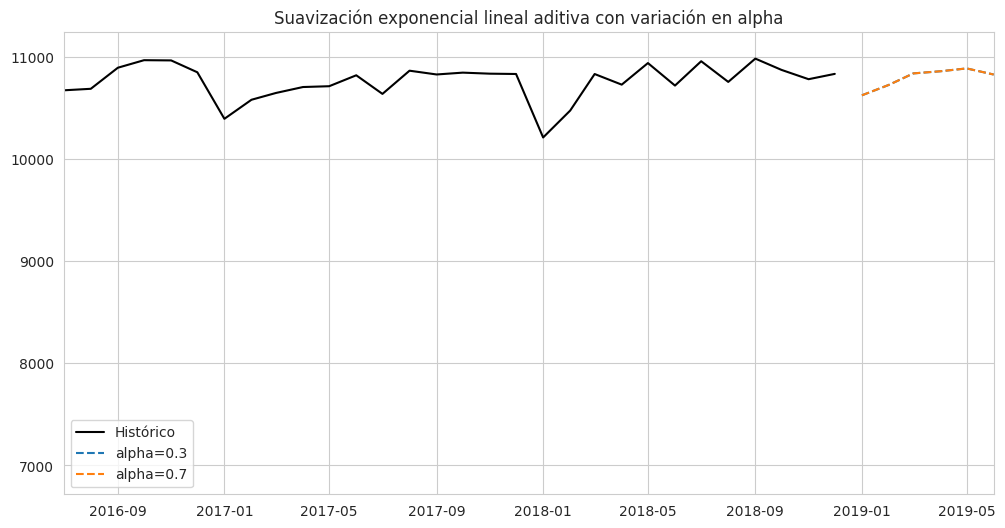

In [ ]:
# modelo aditivo

import matplotlib.pyplot as plt
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

plt.figure(figsize=(12,6))

# Serie completa
plt.plot(train_td.index,
         train_td["Ocupados"],
         color="black",
         label="Histórico")

ets_model = ETSModel(
    endog=train_td["Ocupados"],
    error="add",
    trend="add",
    seasonal="add",
    seasonal_periods=6,
    damped_trend=True
)

# Primer escenario
ets_result = ets_model.fit(
    smoothing_level=0.1,
    smoothing_trend=0.3,
    smoothing_seasonal=0.2,
    damping_trend=0.85,
    optimized=False
)

# Segundo escenario
ets_result2 = ets_model.fit(
    smoothing_level=0.7,
    smoothing_trend=0.3,
    smoothing_seasonal=0.2,
    damping_trend=1,
    optimized=False
)


forecast = ets_result.forecast(6)
forecast2 = ets_result2.forecast(6)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


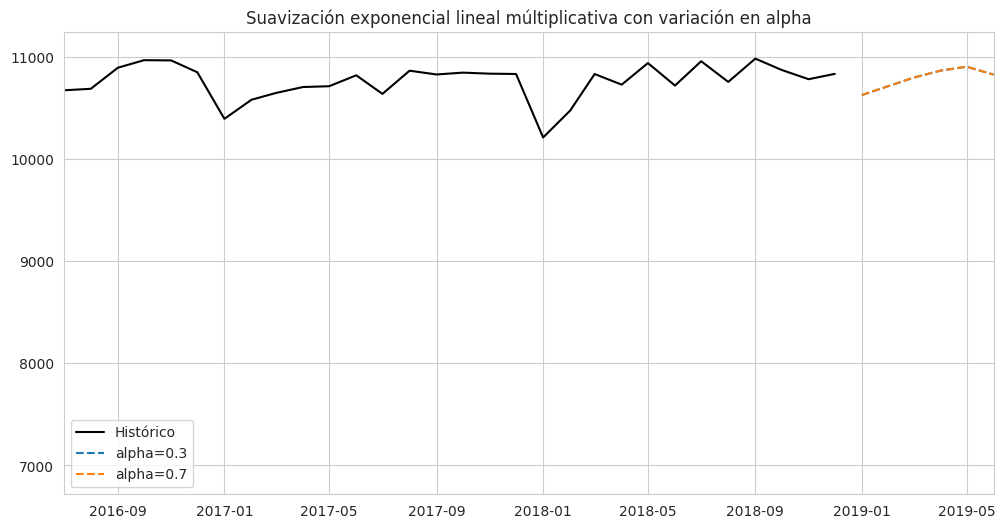

In [ ]:
# modelo múltiplicativo


import matplotlib.pyplot as plt
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

plt.figure(figsize=(12,6))

# Serie completa
plt.plot(train_td.index,
         train_td["Ocupados"],
         color="black",
         label="Histórico")

ets_model2 = ETSModel(
    endog=train_td["Ocupados"],
    error="add",
    trend= "add",
    seasonal="mul",
    seasonal_periods=6,
    damped_trend=True
)

# Tercer escenario
ets_result = ets_model2.fit(
    smoothing_level=0.1,
    smoothing_trend=0.3,
    smoothing_seasonal=0.2,
    damping_trend=0.85,
    optimized=False
)

# Cuarto escenario
ets_result2 = ets_model2.fit(
    smoothing_level=0.7,
    smoothing_trend=0.3,
    smoothing_seasonal=0.2,
    damping_trend=0.85,
    optimized=False
)


forecast3 = ets_result.forecast(6)
forecast4 = ets_result2.forecast(6)


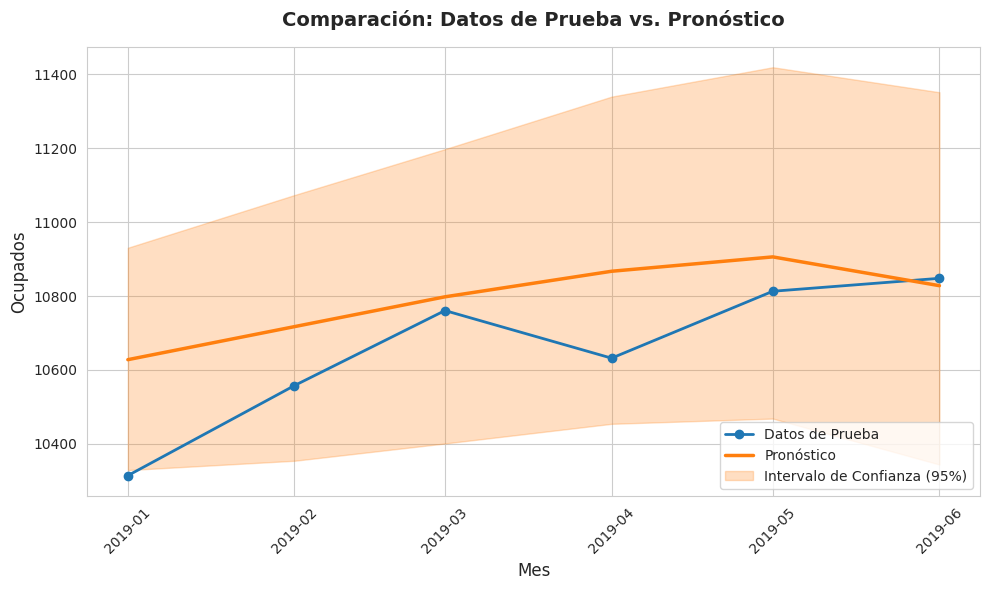

In [ ]:
# 2. Generar pronóstico e intervalos a 6 meses
import matplotlib.pyplot as plt
import seaborn as sns
point_forecast = ets_result.forecast(6)
ci = ets_result.get_prediction(
    start=point_forecast.index[0], end=point_forecast.index[-1]
)
conf_forecast = ci.pred_int(alpha=0.05)
conf_forecast.columns = ["LI_95%", "LS_95%"]

# Alinear los datos de prueba (últimos 6 meses para comparar con el pronóstico)
df_test = test_td.iloc[-6:]

# 3. Construir el gráfico
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")  # Fondo limpio con cuadrícula gris


plt.plot(
    df_test.index,
    df_test["Ocupados"],
    marker="o",
    color="#1f77b4",
    linewidth=2,
    label="Datos de Prueba",
)


plt.plot(
    point_forecast.index,
    point_forecast,
    color="#ff7f0e",
    linewidth=2.5,
    label="Pronóstico",
)


plt.fill_between(
    conf_forecast.index,
    conf_forecast["LI_95%"],  # Límite inferior
    conf_forecast["LS_95%"],  # Límite superior
    color="#ff7f0e",  # Mismo color del pronóstico
    alpha=0.25,  # Transparencia para que no tape las líneas (25%)
    label="Intervalo de Confianza (95%)",
)


plt.title(
    "Comparación: Datos de Prueba vs. Pronóstico",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Mes", fontsize=12)
plt.ylabel("Ocupados", fontsize=12)
plt.xticks(rotation=45)  # Rotar fechas para que no se amontonen


plt.legend(loc="lower right", frameon=True)

# Ajuste final y visualización
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import root_mean_squared_error

# y_true: actual ground truth values
# y_pred: predicted values from your model
rmse = root_mean_squared_error(test_td, forecast)
rmse2 = root_mean_squared_error(test_td, forecast2)
rmse3 = root_mean_squared_error(test_td, forecast3)
rmse4 = root_mean_squared_error(test_td, forecast4)
print(f"Primer escenario {rmse:.2f}")
print(f"Segundo escenario {rmse2:.2f}")
print(f"Tercer escenario {rmse3:.2f}")
print(f"Cuarto escenario {rmse4:.2f}")

Primer escenario 178.17
Segundo escenario 178.17
Tercer escenario 177.65
Cuarto escenario 177.65


In [ ]:
import numpy as np

# Opción A: Ver el promedio real de tu test
promedio_real = test_td["Ocupados"].mean()
error_porcentual_aproximado = (rmse / promedio_real) * 100

print(f"El RMSE representa un error aprox del: {error_porcentual_aproximado:.2f}%")

# Opción B: Ver el promedio real de tu test
promedio_real2 = test_td["Ocupados"].mean()
error_porcentual_aproximado2 = (rmse2 / promedio_real) * 100

print(f"El RMSE representa un error aprox del: {error_porcentual_aproximado2:.2f}%")

# Opción A: Ver el promedio real de tu test
promedio_real3 = test_td["Ocupados"].mean()
error_porcentual_aproximado3 = (rmse3 / promedio_real3) * 100

print(f"El RMSE representa un error aprox del: {error_porcentual_aproximado3:.2f}%")

# Opción A: Ver el promedio real de tu test
promedio_real4 = test_td["Ocupados"].mean()
error_porcentual_aproximado4 = (rmse4 / promedio_real4) * 100


print(f"El RMSE representa un error aprox del: {error_porcentual_aproximado4:.2f}%")


El RMSE representa un error aprox del: 1.67%
El RMSE representa un error aprox del: 1.67%
El RMSE representa un error aprox del: 1.67%
El RMSE representa un error aprox del: 1.67%


In [ ]:
import pandas as pd
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

# 1. Ajustar el "Primer escenario" con parámetros fijos (optimized=False)
ets_model = ETSModel(
    train_td["Ocupados"],
    error="add",
    trend="add",
    seasonal="mul",
    seasonal_periods=12,
    damped_trend=True
)

# Pasamos los parámetros manuales al fit
ets_result = ets_model.fit(
    smoothing_level=0.1,
    smoothing_trend=0.3,
    smoothing_seasonal=0.2,
    damping_trend=0.85,
    optimized=False
)

# 2. Pronóstico para los siguientes 6 meses (h = 6)
point_forecast = ets_result.forecast(6)

# 3. Obtener intervalos de confianza al 95% (alpha = 0.05)
ci = ets_result.get_prediction(
    start=point_forecast.index[0],
    end=point_forecast.index[-1]
)
conf_forecast = ci.pred_int(alpha=0.05)

# 4. Construir y estructurar la tabla final
tabla_pronostico = pd.concat([point_forecast, conf_forecast], axis=1)
tabla_pronostico.columns = ['Pronostico', 'LI_95%', 'LS_95%']

# Opcional: renombrar el índice para que quede estético
tabla_pronostico.index.name = 'Mes'

# Mostrar la tabla
print(tabla_pronostico)

              Pronostico        LI_95%        LS_95%
Mes                                                 
2019-01-01  10335.072006  10126.434595  10557.275042
2019-02-01  10533.634310  10281.224228  10795.412400
2019-03-01  10617.283934  10350.852939  10898.670747
2019-04-01  10627.035371  10330.330900  10951.184452
2019-05-01  10695.724960  10356.793284  11045.904280
2019-06-01  10652.066321  10296.774021  11038.206672


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: smoothing_trend, damping_trend, smoothing_seasonal, optimized, smoothing_level. After release 0.14, this will raise.
  warnings.warn(
